# Druk, temperatuur en energie

## Doelen

Om het gedrag van een gas beter te begrijpen moeten we de microscopische eigenschappen van ons model (zoals massa, snelheid, impuls en energie per deeltje) nu verbinden aan de macroscopische eigenschappen van het systeem (zoals druk en temperatuur). We gaan ons model dus uitbreiden met code om deze macroscopische eigenschappen te berekenen.

Eerst nemen we alle delen over van de code die we opnieuw moeten gebruiken:
- class voor particles
- functies voor detecteren botsingen
- (toelichten van een snellere manier van programmeren).

Daarna voeren we de code toe voor de nieuwe macroscopische eigenschappen:
- een functie schrijven voor de temperatuur
- een functie schrijven voor de druk

En dan maken we een simulatie, controleren we de resultaten en verbeteren we eventueel de code. 

## Laden van alle code die we al ontwikkeld hebben

Zoals de juiste pakketten vaan Python en de constanten van onze simulatie:

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

BOX_SIZE_0 = 10                # Hoogte en lengte startvolume
N = 40                         # Aantal deeltjes
V_0 = 1                        # Startsnelheid van deeltjes
RADIUS = 0.3 # pas aan         # Straal van moleculen
DT = 0.1 * RADIUS / V_0        # Tijdstap om geen botsing te missen

De klasse voor de gasmoleculen en de functies voor hun onderlinge interactie:

In [66]:
class ParticleClass:
    def __init__(self, m, v, r, R):
        """ maakt een deeltje (constructor) """
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = R

    def update_position(self):
        """ verandert positie voor één tijdstap """
        self.r += self.v * DT 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
def collide_detection(p1: ParticleClass, p2: ParticleClass) -> bool:
    """ Geeft TRUE als de deeltjes overlappen """
    return np.linalg.norm(p1.r - p2.r) < (p1.R + p2.R)


def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

Het volume met de 'oude' randvoorwaarden. Dit zijn niet de randvoorwaarden van het vorige werkblad, maar de randvoorwaarden die je in Q1 hebt gebruikt. Hierbij botsen de deeltjes elastisch met de wanden van het volume. 

In [67]:
def box_collision(particle: ParticleClass):
    ''' botsing met harde wanden '''
    if abs(particle.r[0]) + particle.R > BOX_SIZE_0/2: 
        particle.v[0] = -particle.v[0]                                        # Omdraaien van de snelheid
        particle.r[0] = np.sign(particle.r[0]) * (BOX_SIZE_0/2 - particle.R)  # Zet terug net binnen box                 
    if abs(particle.r[1]) + particle.R > BOX_SIZE_0/2: 
        particle.v[1] = -particle.v[1]     
        particle.r[1] = np.sign(particle.r[1]) * (BOX_SIZE_0/2 - particle.R) 

Het uitvoeren en samennemen van deze functies over een lijst met deeltjes:

In [68]:
def create_particles(particles):
    """ Leegmaken en opnieuw aanmaken van deeltjes  in lijst """
    particles.clear()
    for i in range(N):
        vx = np.random.uniform(-V_0, V_0)
        vy = np.random.choice([-1, 1]) * np.sqrt(V_0**2 - vx**2)        
        pos = np.random.uniform(-BOX_SIZE_0/2 + RADIUS, BOX_SIZE_0/2 - RADIUS, 2)
        particles.append(ParticleClass(m=1.0, v=[vx, vy], r=pos, R=RADIUS))
        
def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])

def handle_walls(particles):
    """ botsing met wanden controleren voor alle deeltjes in lijst """
    for p in particles:
        box_collision(p)

def take_time_step(particles):
    """ zet tijdstap voor een lijst deeltjes en verwerk alle botsingen onderling en met wanden """
    for p in particles:
        p.update_position()
    handle_collisions(particles)
    handle_walls(particles)  


## Het draaien van een eerste simulatie ter controle

Laten we het eerst zo eenvoudig mogelijk maken en controleren of het lukt om honderd tijdstappen te zetten met de hierboven gedefinieerde functies. Als resultaat beperken we ons tot het plotten van de posities van de deeltjes en hun snelheden.

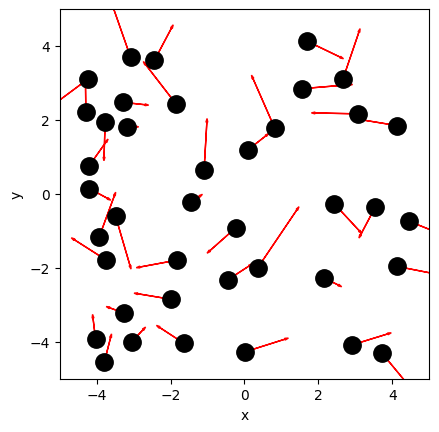

In [69]:
particles = []
create_particles(particles)
for i in range(100):
    take_time_step(particles)

plt.figure()
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.xlim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
plt.ylim(-BOX_SIZE_0/2, BOX_SIZE_0/2)

for p in particles:
    plt.plot(p.r[0], p.r[1], 'k.', ms=25)
    plt.arrow(p.r[0], p.r[1], p.v[0], p.v[1], 
              head_width=0.05, head_length=0.1, color='red')
plt.show()

## Temperatuur

Het boek behandelt de microscopische formules helemaal niet, maar de thermische energie van een gas is niets anders dan de statisch gemiddelde kinetische energie van de deeltjes waaruit het gas bestaat. Nu is er van alles te zeggen over deze statistiek, maar voor nu gaan we daar even aan voorbij. Dat is onderwerp van het vak Fysische Transportverschijnselen dat je in het tweede jaar zult krijgen. De temperatuur wordt gegeven door:

$$
    \frac{n}{2}kT=\frac{1}{2}m\left<v^2\right>
$$

Hierbij is 

- $k$ de constante van Boltzmann ($1,380649\cdot10^{-23} \text{ JK}^{-1}$)
- $n$ het aantal vrijheidsgraden (het aantal dimensies waarin het gas kan bewegen)
- $T$ de temperatuur (in Kelvin)
- $m$ de massa van de deeltjes (in kg)
- $v$ de snelheid van de deeltjes (in $\text{ms}^{-1}$)

```{exercise}
Schrijf een functie die de temperatuur van het gas in onze simulatie bepaalt:
```

In [70]:
def temperature(particles) -> float:
    temp = 0.0 
    # Geef hier je oplossing
    return temp

In [71]:
# SOLUTION
def temperature(particles) -> float:
    temp = 0.0
    for p in particles:
        temp += p.kin_energy
    temp = temp / len(particles)
    return temp

```{exercise}
Gebruik deze functie om een simulatie te maken waarin je de temperatuur als functie van de tijdstap voor 100 tijdstappen plot.
```

```{exercise}
De assen moeten natuurlijk ook eenheden hebben. In het vorige werkblad heb je de vermenigvuldigingsfactoren en eenheden bij de constanten van deze simulatie bepaald. Breid de berekening uit, zodat de eenheden kloppen bij het model dat we probeerden weer te geven.
```

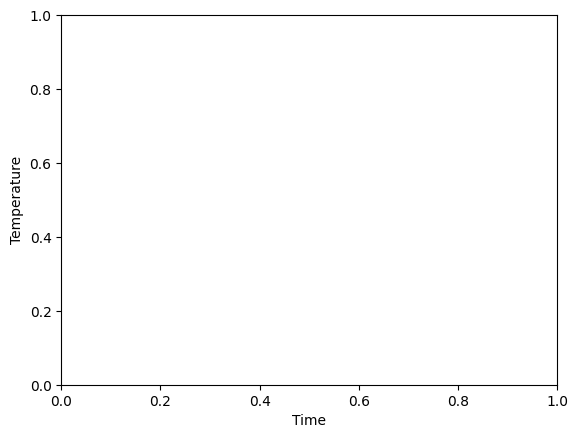

In [72]:
# ruimte voor uitwerking

particles = []
temperatures = []

create_particles(particles)
for i in range(100):
    take_time_step(particles)
    # vastleggen van temperatuur per tijdstap

plt.figure()
plt.xlabel('Time')
plt.ylabel('Temperature')
# plotten van tijd tegen temperatuur

plt.show()

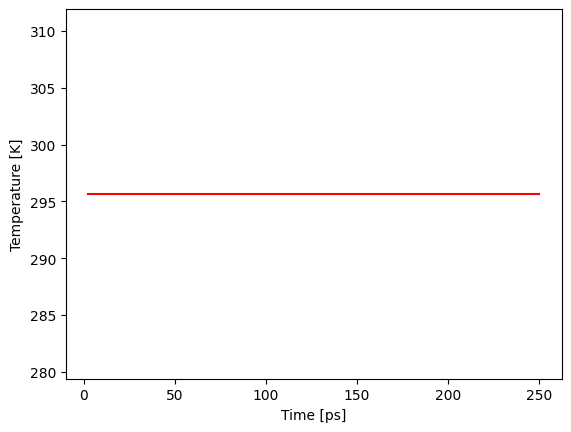

In [73]:
# voorbeelduitwerking

particles = []
temperatures = np.zeros(100, dtype=float)
times = np.linspace(1, 100, 100)

create_particles(particles)
for i in range(100):
    take_time_step(particles)
    temperatures[i] = temperature(particles)

plt.figure()
plt.xlabel('Time [ps]')
plt.ylabel('Temperature [K]')

times = times * 2.5
temperatures = np.asarray(temperatures) * 30 * 1.7E-27 * (1E-9 / 2.5E-12)**2 / 1.38E-23

plt.plot(times, temperatures, '-r')

plt.show()

## Druk

De druk van een gas is lastiger te berekenen dan de temperatuur. Het is letterlijk de druk van de gasmoleculen tegen de wanden van het volume. 

$$ 
    P = \frac{F}{A} \stackrel{2D}{=} \frac{F}{l} = \frac{dp / dt}{l} \approx \frac{\Delta p}{l\Delta t} 
$$

Hierbij is:

- $P$ de druk (hoofdletter om te onderscheiden t.o.v. impuls)
- $A$ het oppervlak van de wand (voor de 3D situatie)
- $l$ de lengte van de wand (voor de 2D situatie)
- $p$ het impuls van het gasdeeltje

In de laatste stap hebben we de afgeleide vervangen door het verschil over een tijdstap, omdat die informatie makkelijk uit onze simulatie te halen is. Om de druk op de wand te bepalen, moeten we dus de verandering van de impuls van de wand bepalen. In het Nederlands wordt de verandering van impuls ook wel 'stoot' genoemd. Onhandig is dat de Engelse term hiervoor 'impulse' is.

De wand in ons experiment staat natuurlijk stil, maar ook hier geldt de wet van behoud van impuls (let op: dit is de Nederlandse impuls, die in het Engels 'momentum' heet). We kunnen dus kijken naar de verandering van impuls van de moleculen op het moment dat deze botsen met de wand. Daarvoor maken we een nieuwe versie van de functie `handle_walls` die voor het afhandelen van deze botsing wordt aangeroepen.

We kiezen ervoor om de botsingen met de wanden hierbij te splitsen in twee functies: eentje voor de verticale wanden en een voor de horizontale wanden. Dat lijkt nu nog wat overdreven, maar als het model straks verder wordt uitgebreid houdt dit de code het meest overzichtelijk.

```{note}
Kan hier ook vragen stellen over variabelen in de functie, immutable types en globale variabelen. 
```

In [74]:
impulse_outward = 0.0
pressure = 0.0

def top_down_collision(particle: ParticleClass):
    global impulse_outward
    if abs(particle.r[1]) + particle.R > BOX_SIZE_0 / 2:
        particle.r[1] = np.sign(particle.r[1]) * (BOX_SIZE_0/2 - particle.R)
        impulse_outward += abs(particle.momentum[1]) * 2
        particle.v[1] *= -1
    
def left_right_collision(particle: ParticleClass):
    global impulse_outward
    if abs(particle.r[0]) + particle.R > BOX_SIZE_0 / 2:
        particle.r[0] = np.sign(particle.r[0]) * (BOX_SIZE_0/2 - particle.R)
        impulse_outward += abs(particle.momentum[0]) * 2
        particle.v[0] *= -1
    
def handle_walls(particles):
    """ botsing met wanden controleren voor alle deeltjes in lijst en bepaling druk """
    global pressure, impulse_outward       # om pressure buiten de functie te kunnen gebruiken
    impulse_outward = 0.0
    for p in particles:
        left_right_collision(p)
        top_down_collision(p)
    pressure = (impulse_outward) / (4 * BOX_SIZE_0 * DT)  # omtrek volume is oppervlak (2D sim)


```{exercise}
Maak nu een simulatie waarin je de druk als functie van de tijd toont gedurende 100 tijdstappen.
```

Je zal zien dat deze grafiek niet een mooie vlakke vorm zal hebben.

In [75]:
# Geef je oplossing

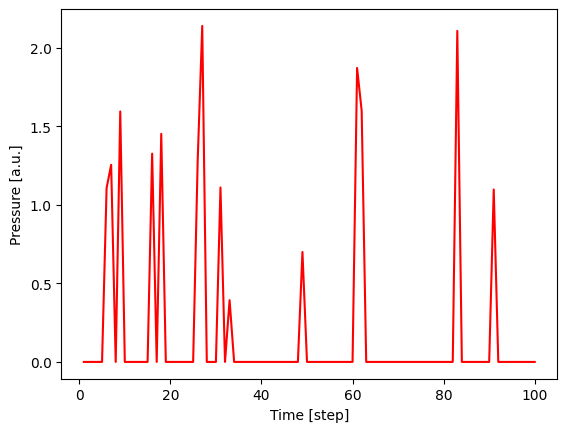

In [76]:
# OPLOSSING

particles = []
pressures = np.zeros(100, dtype=float)
times = np.linspace(1, 100, 100)

create_particles(particles)
for i in range(100):
    take_time_step(particles)
    pressures[i] = pressure

plt.figure()
plt.xlabel('Time [step]')
plt.ylabel('Pressure [a.u.]')

plt.plot(times, pressures, '-r')

plt.show()

## Verbeteren van code: middelen

De grafiek voor de druk bestaat uit een achtergrond op de waarde 0 en daarop een serie scherpe pieken. Een piek komt overeen met een tijdstap waar er toevallig een atoom met de wanden botst. Om deze grafiek meer constant te maken kunnen we het aantal deeltjes sterk verhogen door een veel groter volume te modelleren, maar dat kost ons veel meer rekenkracht. Een goedkoper alternatief bestaat uit het middelen van de druk over de tijd. Fysisch is daar geen echte reden voor, maar ook meetinstrumenten in het laboratorium bepalen hun meetwaarde gedurende een tijdsinterval om hun ruis te verlagen. 

In de code doen we dit door de druk in de $i$-de tijdstap ($P_i$) niet volledig te laten bepalen door de druk tijdens de tijdstap waarin de simulatie plaatsvindt ($P$), maar door de druk in de vorige tijdstap ($P_{i-1}$) mee te nemen. 

$$ 
    P_{i} = \alpha * P_{i-1} + (1-\alpha) * P 
$$

Door de factoren op deze manier netjes te kiezen, verandert de netto waarde voor de druk niet want voor $|\alpha| < 1$ geldt:

$$ 
    \sum_{i=0}^{\infty}(\alpha^k)(1-\alpha) =  \frac{1}{1-\alpha}(1-\alpha) = 1 
$$

In [77]:
def handle_walls(particles):
    """ botsing met wanden controleren voor alle deeltjes in lijst en gemiddeld bepaling druk """
    global pressure, impulse_outward       # om pressure buiten de functie te kunnen gebruiken
    impulse_outward = 0.0
    for p in particles:
        left_right_collision(p)
        top_down_collision(p)    
    pressure = 0.9 * pressure + 0.1 * impulse_outward / (4 * BOX_SIZE_0 * DT)  # omtrek volume is oppervlak (2D sim)

```{exercise}
Kopieer nu je code voor de simulatie waarin je de druk als functie van de tijd hebt geplot naar onderstaand veld en voer de simulatie nogmaals uit met de nieuwe definitie voor de functie `handle_walls`
```

In [78]:
# RUIMTE VOOR GEKOPIEERDE FUNCTIE

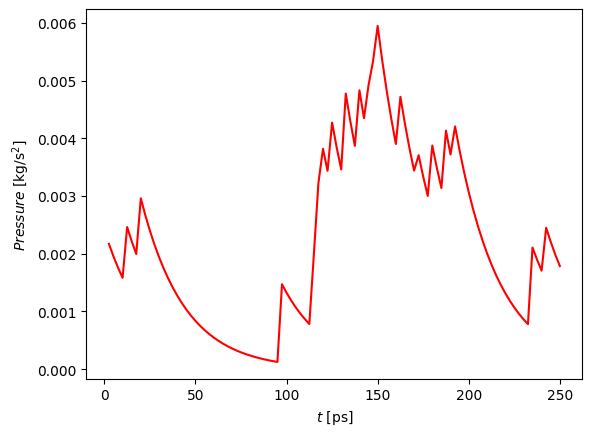

In [83]:
# OPLOSSING

particles = []
pressures = np.zeros(100, dtype=float)
times = np.linspace(1, 100, 100)

create_particles(particles)
for i in range(100):
    take_time_step(particles)
    pressures[i] = pressure

plt.figure()
plt.xlabel('$t$ [ps]')
plt.ylabel('$Pressure$ [kg/s$^2$]')

times *= 2.5
# p = F/A = N/m = kg m s^-2 / m = kg /s^-2
pressures *= 30 * 1.7E-27 / 2.5e-12**2

plt.plot(times, pressures, '-r')

plt.show()

Met de middeling kan je beter zien wat de gemiddelde waarde voor de druk in dit systeem is. Als dit voor jouw simulatie lastig is kan je de factoren aanpassen in de functie 'handle_walls`, zodat je over een langere periode het gemiddelde neemt. 

```{exercise}
We kunnen de gevonden druk nu wel uitdrukken in SI-eenheden met behulp van de voorfactoren die we voor de constanten hebben gevonden, maar daar komt niet het juiste antwoord uit. Kan je verklaren waardoor dit komt?
```

Om te voorspellen welke waarde de druk hier dan wel moet hebben, moeten we kijken naar de statistiek van een ensemble deeltjes. Dit is geen onderdeel van de klassieke thermodynamica in dit vak, maar wordt volgend jaar behandeld bij de Statistische Fysica. 

# Vanaf hier geen inhoudelijke aanpassingen meer gedaan. Alleen compatible gemaakt met code. 

Laten we kijken naar de energie distributie:

ValueError: Too many bins for data range. Cannot create 13 finite-sized bins.

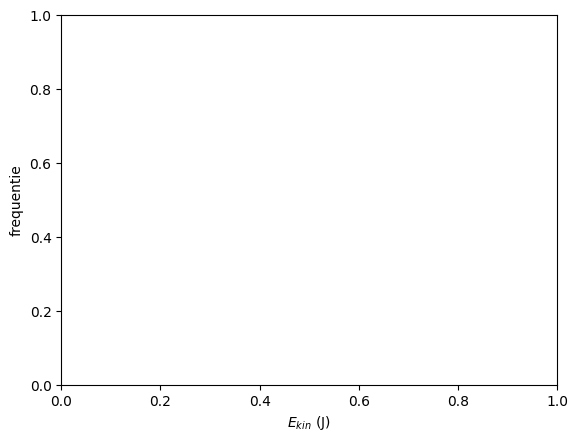

In [80]:
create_particles(particles)
for p in particles:
    p.kin_energy
energies = [p.kin_energy for p in particles]

plt.figure()
plt.xlabel('$E_{kin}$ (J)')
plt.ylabel('frequentie')
plt.hist(energies,bins='auto',density='True')

plt.show()

Triggert een error. Die error wordt veroorzaakt doordat er te weinig variatie is in de data om een histogram te maken.

```{exercise}
Hadden we dat kunnen verwachten? Waarom?
```

```{exercise}
Wat verwacht je van de energie distributie na het draaien van de simulatie?
```

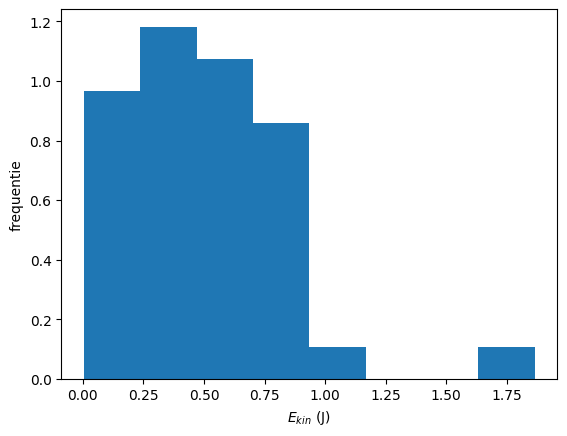

In [ ]:
create_particles(particles)
for i in range(100):
    take_time_step(particles)
for p in particles:
    p.kin_energy
energies = [p.kin_energy for p in particles]

plt.figure()
plt.xlabel('$E_{kin}$ (J)')
plt.ylabel('frequentie')

plt.hist(energies,bins='auto',density='True')

plt.show()

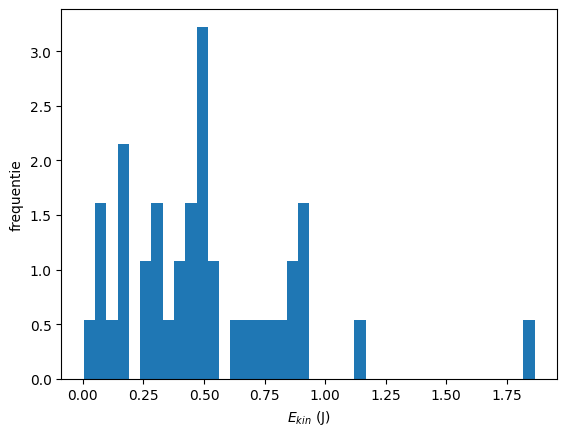

In [ ]:
energies = [p.kin_energy for p in particles]

plt.figure()
plt.xlabel('$E_{kin}$ (J)')
plt.ylabel('frequentie')

plt.hist(energies,bins=40,density='True')

plt.show()

## Temperatuur

iets als gem. kin. e

schrijf een functie die de temperatuur bepaald op basis van gemiddelde kinetische.


    @property
    def temperature(self):
        en = 0.0
        for atom in self.atoms:
            en += 0.5 * atom.mass * np.dot(atom.velocity, atom.velocity)
        return en / len(self.atoms)

# Druk

botsing met wand, dan impuls verandering $p=2mv$

som van botsingen met wand gedeeld door opp van de wand (4 boxsize)

dus dan gaan werken in de boxcollision:


In [ ]:
# DEZE CODE GEHEEL NIET AANGERAAKT

# class ParticleClass:
#     # Het maken van het deeltje
#     def __init__(self, m, v, r, R):
#         self.m = m                         
#         self.v = np.array(v, dtype=float)  
#         self.r = np.array(r, dtype=float)  
#         self.R = np.array(R, dtype=float)  

#     # Het updaten van de positie, eventueel met zwaartekracht
#     def update_position(self, dt):
#         self.r += self.v * dt # + 1/2 * a * dt**2  
    
#     # Het updaten van de snelheid door zwaartekracht
#     # def update_velocity(self, a, dt):
#     #     """Update the particle's velocity."""
#     #     self.v += a*dt
    
#     # Het bepalen of er een botsing plaats vindt
#     def collide_detection(self, other):
#         return np.linalg.norm(self.r - other.r) < (self.R + other.R)
    
#     # Harde wand
#     def box_collision(self, box_length):
#         impulse = np.zeros(2)
#         p_before = self.momentum.copy()

#         for i in [0, 1]:
#             if abs(self.r[i]) + self.R > box_length:
#                 self.v[i] *= -1
#                 self.r[i] = np.sign(self.r[i]) * (box_length - self.R)

#         p_after = self.momentum
#         impulse = p_after - p_before  # verandering in impuls (Δp)
#         return -impulse  # stoot op de wand = negatieve Δp van deeltje
            
#     @property
#     def momentum(self):
#         return self.m * self.v
    
#     @property
#     def kin_energy(self):
#         return 1/2 * self.m * np.dot(self.v, self.v)
    
    

    
# druk = np.sum(total_impulse) / (4 * Box_length * dt)  # 2D: omtrek = 4*L    